## Lab 14: SciPy

### Task 1: Constants
-  Print 5 different physical constants.
-  Convert 10 miles to meters using SciPy constants.

In [4]:
# Importing all the required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from scipy import special
from scipy import interpolate

In [14]:
# Print 5 physical constants
print("The speed of the light (m/s) is:",constants.speed_of_light)
print("Plank's Constant (J.s) is:",constants.h)
print("Gravitational Constant is:", constants.G)
print("Avagrado Number is :",constants.N_A)
print("Electron Mass (Kg):", constants.m_e)

# Converting 10 miles into meters
# Initialize the variable
miles_to_convert = 10
meters = miles_to_convert * constants.mile # Scipy constant

print("\n10 miles in meters: ", meters)

The speed of the light (m/s) is: 299792458.0
Plank's Constant (J.s) is: 6.62607015e-34
Gravitational Constant is: 6.6743e-11
Avagrado Number is : 6.02214076e+23
Electron Mass (Kg): 9.1093837015e-31

10 miles in meters:  16093.439999999999


### Task 2: Special Functions
- Plot Bessel functions of order 1 and 2.
- Calculate factorial, gamma, and error function for given values.
- Explore special.sph_harm for spherical harmonics.

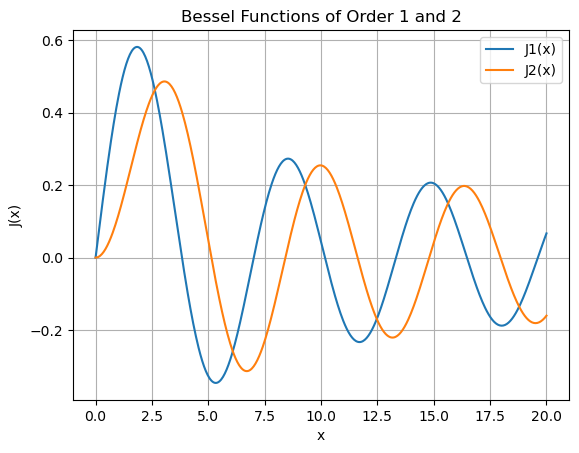

In [5]:
x = np.linspace(0,20,500)

y1 = special.jv(1,x) # Bessel function of order 1
y2 = special.jv(2,x) # Bessel function of order 2

plt.plot(x,y1,label="J1(x)")
plt.plot(x,y2,label="J2(x)")
plt.title("Bessel Functions of Order 1 and 2")
plt.xlabel("x")
plt.ylabel("J(x)")
plt.legend()
plt.grid()
plt.show()

In [15]:
# Factorial , Gamma, Error Function
n = int(input("Enter value for factorial(n): "))
x = float(input("Enter value for Gamma(x):"))
e = float(input("Enter value for Error Func(e):"))

print("Factorial of x is:",special.factorial(n))
print("Gamma for the value x is: ", special.gamma(x))
print("Error Function erf for the value e is: ",special.erf(e))

Enter value for factorial(n):  5
Enter value for Gamma(x): 3.5
Enter value for Error Func(e): 1.2


Factorial of x is: 120.0
Gamma for the value x is:  3.323350970447843
Error Function erf for the value e is:  0.9103139782296353


In [17]:
# Spherical Harmonics (sph_harm)
m = 1 # Order
l = 2 # degree
phi = np.pi / 2 # Azimuthal angle
theta = np.pi / 3 # Polar angle

result = special.sph_harm(m,l,phi, theta)
print("Spherical Harmonic Y_lm: ", result)

Spherical Harmonic Y_lm:  (-2.0483642701200862e-17-0.3345232717786446j)


### Task 3: Interpolation
- Interpolate a set of temperature measurements using linear and cubic interpolation.
- Perform 2D interpolation for a small dataset of height measurements.
- Compare linear vs cubic interpolation visually.

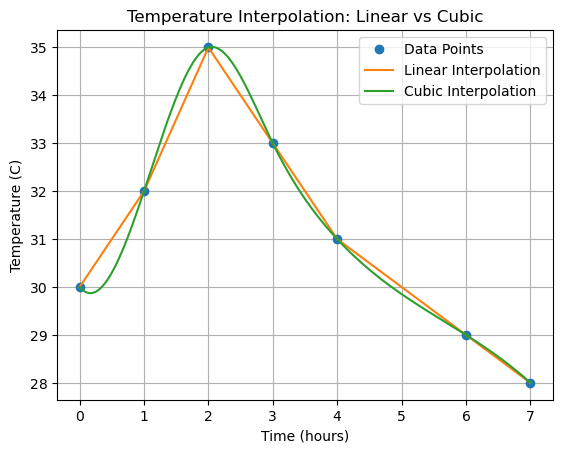

In [24]:
# Interpolation of temp measuremnts
x = np.array([0,1,2,3,4,6,7]) # Time (hours)
temp = np.array([30,32,35,33,31,29,28])

# Create Interpolation functions
linear_func = interpolate.interp1d(x, temp, kind="linear")
cubic_func = interpolate.interp1d(x,temp, kind="cubic")

# Generate smooth values
x_new = np.linspace(0,7,200)

# Visualization
plt.plot(x, temp, "o", label="Data Points")
plt.plot(x_new, linear_func(x_new), label="Linear Interpolation")
plt.plot(x_new, cubic_func(x_new), label="Cubic Interpolation")
plt.legend()
plt.title("Temperature Interpolation: Linear vs Cubic")
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (C)")
plt.grid()
plt.show()



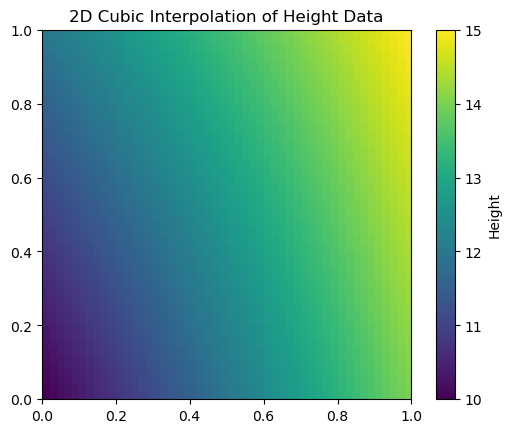

In [34]:
# 2D Interpolation of Height Measurements
from scipy.interpolate import griddata

# Sample 2D points (x and y ) and their height values z
two_D_points = np.array([[0,0], [0,1], [1,0], [1,1]])
height_values = np.array([10,12,14,15])

# New grid to interpolate on
grid_x, grid_y = np.mgrid[0:1:50j, 0:1:50j]

grid_z = griddata(two_D_points, height_values, (grid_x, grid_y), method = "cubic")

# Visualization
plt.imshow(grid_z.T, extent = (0,1,0,1), origin = "lower")
plt.colorbar(label="Height")
plt.title("2D Cubic Interpolation of Height Data")
plt.show()


### Task 4: Application
- Use Bessel function to simulate a simple wave pattern.
- Use interpolation to fill missing values in a dataset.

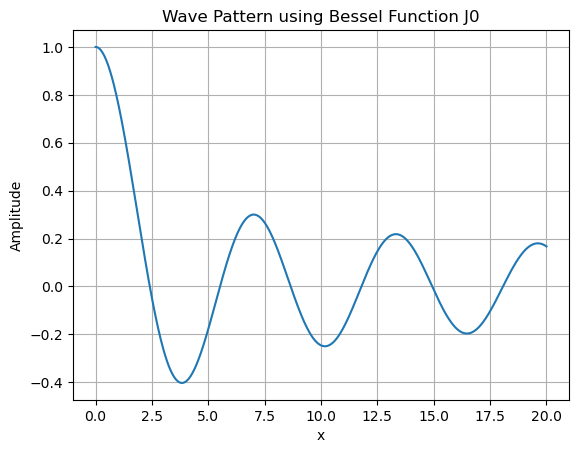

In [6]:
x = np.linspace(0,20,500)
wave = special.jv(0, x) # Bessel J0 behaved like a wave

# Visualization
plt.plot(x,wave)
plt.title("Wave Pattern using Bessel Function J0")
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [16]:
# Using Interpolations to fill missing Dataset values
from scipy.interpolate import interp1d
# Dataset with missing values
x = np.array([0,1,2,3,4,5])
y = np.array([1,2,-1,7,-1,11])

# Selection of valid data for Interpolation
valid_x = x[y != -1]
valid_y = y[y != -1]

# Creating an Interpolation model
f = interp1d(valid_x,valid_y, kind="linear")

# Fill missing values
y_filled = y.copy()
missing_indices = np.where(y == -1)[0]

for idx in missing_indices:
    y_filled[idx] = f(x[idx])


print("Original Data: ", y)
print("After Interpolation: ",y_filled)

Original Data:  [ 1  2 -1  7 -1 11]
After Interpolation:  [ 1  2  4  7  9 11]
